## Fresnel Rhomb ##

Here we do a first order design of a Fresnel Rhomb, to introduce some of the solid modeling capabilities of prtLab.  A Fresnel Rhomb utilizes total internal reflection (tir) to generate a phase difference between different polarization eigenstates.  

To get started, let's look at the fresnel reflection coefficients for tir:

$$r_s = \frac{\cos(\theta) - i\sqrt{\sin^2(\theta) - n^2}}{\cos(\theta) + i\sqrt{\sin^2(\theta)- n^2}}$$

$$r_p = \frac{n^2 \cos(\theta) - i\sqrt{\sin^2(\theta) - n^2}}{n^2 \cos(\theta) + i\sqrt{\sin^2(\theta) - n^2}}$$


Let's assume the index in the incident medium is 1.5, and in the exit medium it is 1.  So the critical angle is ~41 degrees.  Let's plot the phase difference as a function of theta



In [1]:
addpath(genpath('../../'));
pwd


ans = '/Users/jeremy/Downloads/work/prtLab/docs/source'

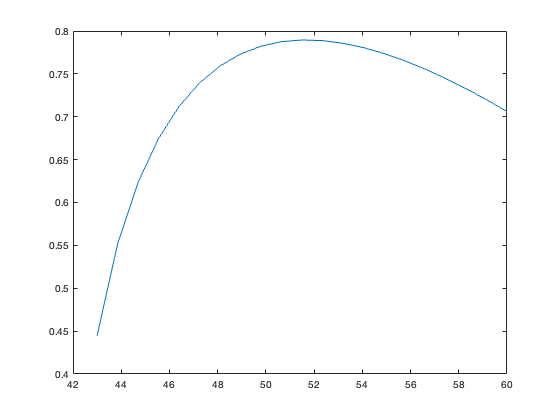

In [2]:
function [rs, rp] = fresnel_tir_coefficients(theta_deg, n)
 

    % Convert incident angle from degrees to radians
    theta = deg2rad(theta_deg);
    
    sqrt_term = sqrt(sin(theta).^2-n^2);
    cos_theta = cos(theta);
    
    rs = (cos_theta - 1i*sqrt_term) ./ (cos_theta + 1i*sqrt_term);
    rp = (n^2 * cos_theta - 1i*sqrt_term) ./ (n^2 * cos_theta + 1i*sqrt_term);
end

angles = linspace(43,60,21);

for ii=1:length(angles)
    [rs, rp] = fresnel_tir_coefficients(angles(ii), 1/1.5);
    fazDiff(ii) = angle(rs)-angle(rp);
end

figure;plot(angles, fazDiff);



A Fresnel Rhomb will have two TIR bounces, so if we can get $\pi$/4  frome each bounce we should be good.  This occurs at roughly 51 degrees.

Now let's turn to the prtLab model of a rhomb.  Example below:  

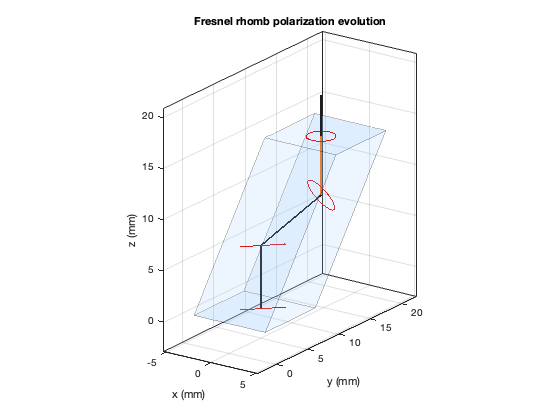

In [4]:
lambda = 0.589; % um
nGlass = 1.5;

rhomb = createFresnelRhombSolid(nGlass, ...
    Length=14, ...
    Height=8, ...
    Width=8, ...
    Shear=11.33, ...
    lambda=lambda/1000, ...
    lambdaUnits="mm");

options = prtDefaultOptions();
options.maxInteractions = 8;
options.minAmplitude = 1e-4;

kIn = [0; 0; 1];
xIn = [0; 5; -2];
Ein = [1; 1]/sqrt(2);


rayOutput = polarizationRayTraceSolid(rhomb, kIn, xIn, Ein, options);

figure;
plotPrtSystem3D(rhomb, rayOutput, ...
    RaySelection="dominant", ...
    PostExtend=4);
title("Fresnel rhomb polarization evolution");


The rhomb object is specified by the length, height, width, and shear.  The dimensions are scale invariant, what matters are the ratios.  To get to ~51 degrees aoi, we want tan(90-51) = s/l.  If we keep l fixed at 14 (arbitrary), then s should be about 11.33.  You can see that when this is done, I start out with 45 degree polarization, and end up with something that is roughly circular.  

This is not very precise and not using a real glass, so setting up a loop with some actual glass data is worthwhile.  



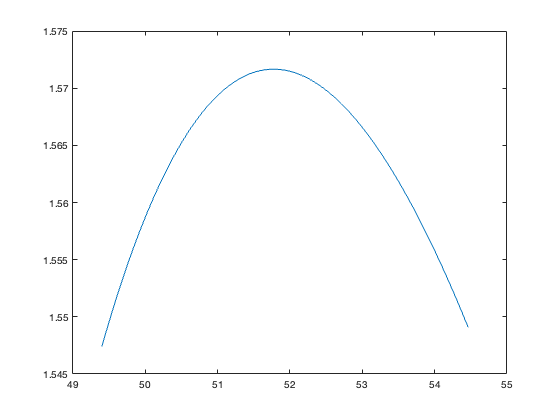

In [5]:
% Test vs shear
shears = linspace(10,12,101);
tta = 0;
kIn = [0; sin(tta*pi/180); cos(tta*pi/180)];
xIn = [0; 5; -2];
Ein = [1; 1]/sqrt(2);

coord = struct('type',"doublePole", ...
    'a_loc',[0;0;1], ...
    'x_o',[1;0;0]);

lambda = .589; % um
nGlass = nPk52aOpticalConstants(lambda);

for ii=1:length(shears)

    rhomb = createFresnelRhombSolid(nGlass, ...
        Length=14, ...
        Height=8, ...
        Width=8, ...
        Shear=shears(ii), ...
        lambda=lambda, ...
        lambdaUnits="um");

    rayOutput = polarizationRayTraceSolid(rhomb, kIn, xIn, Ein, options);

    finalRay = selectDominantFinalRay(rayOutput);
    P = finalRay.P;
    kOut = finalRay.k;
    Jm = transformPtoJones(P, kIn, kOut, coord);


    retardanceVsShear(ii) = calcRetardanceFromJonesMatrix(Jm);
    aoi(ii) = 180/pi*acos(dot([0;0;1],rayOutput.interactions(2).normal));

end

figure;plot(aoi,retardanceVsShear);

Here the shear has been varied, and the total retardance has been calculated as a function of the angle of incidence on the first tir surface.  It is a little hard to see from the plot, but there are two angles that will give a value very close to pi/2 for this wavelength/index.  I chose a shear of 10.84, which is good enough for this example.  

Another advantage of a rhomb is that it is pretty insensitive to wavelength. We can plot the retardance as a function of wavelength to quantify this:

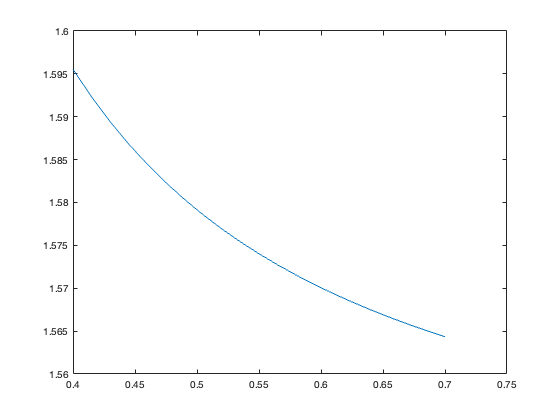

In [6]:
shear = 10.84; % eyeball fit

% Now do vs wavelength

wls = 1/1000*linspace(400,700,21);
tta = 0;
kIn = [0; sin(tta*pi/180); cos(tta*pi/180)];
xIn = [0; 5; -2];
Ein = [1; 1]/sqrt(2);

for ii=1:length(wls)

lambda = wls(ii); % um
nGlass = nPk52aOpticalConstants(lambda);

rhomb = createFresnelRhombSolid(nGlass, ...
    Length=14, ...
    Height=8, ...
    Width=8, ...
    Shear=shear, ...
    lambda=lambda, ...
    lambdaUnits="um");

rayOutput = polarizationRayTraceSolid(rhomb, kIn, xIn, Ein, options);

finalRay = selectDominantFinalRay(rayOutput);
P = finalRay.P;
kOut = finalRay.k;
Jm = transformPtoJones(P, kIn, kOut, coord);

retardanceVsWavelength(ii) = calcRetardanceFromJonesMatrix(Jm);

end

figure;plot(wls,retardanceVsWavelength);


The range here is ~.04 radians or 6 milliwaves, which is pretty insenstiive.  

Of course there are other things you can do, such as looking at angle dependence or looking at tolerance errors of the rhomb.  This example is meant to show what can be done with prtLab.  Other solids can be implemented to evaluate things like beamsplitters.  The core machinery of quantifying the interaction at an interface between two materials (the trace*.m files) works for any object, but the bookkeeping of tracing to the next surface and defining the surface boundaries is a bit more complicated for 3D objects vs the optical design inspired surface model used for the waveplates.  